In [1]:
import numpy as np
import pandas as pd
import nltk

In [3]:
data=pd.read_csv("twitter_training.csv")

In [4]:
data

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [8]:
data.head(5)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [9]:
data.tail()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...
74680,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [12]:
data.describe()

,2401
count,74681.000000
mean,6432.640149
std,3740.423819
min,1.000000
25%,3195.000000
50%,6422.000000
75%,9601.000000
max,13200.000000


In [14]:
data.isnull()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
74676,False,False,False,False
74677,False,False,False,False
74678,False,False,False,False
74679,False,False,False,False


In [20]:
data.isnull().sum

<bound method DataFrame.sum of         2401  Borderlands  Positive  \
0      False        False     False   
1      False        False     False   
2      False        False     False   
3      False        False     False   
4      False        False     False   
...      ...          ...       ...   
74676  False        False     False   
74677  False        False     False   
74678  False        False     False   
74679  False        False     False   
74680  False        False     False   

       im getting on borderlands and i will murder you all ,  
0                                                  False      
1                                                  False      
2                                                  False      
3                                                  False      
4                                                  False      
...                                                  ...      
74676                                              False   

In [24]:
data.shape

(74681, 4)

In [25]:
data.isnull().sum()

2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on borderlands and i will murder you all ,    686
dtype: int64

In [26]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

In [27]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ncs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ncs\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ncs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [38]:
data.columns.tolist()
data.columns = ['ID', 'Game', 'Sentiment', 'Text']

In [39]:
data.columns

Index(['ID', 'Game', 'Sentiment', 'Text'], dtype='object')

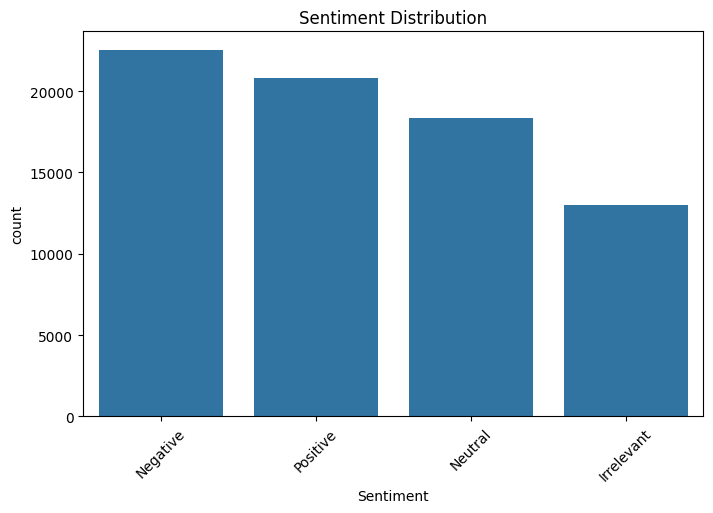

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='Sentiment', order=data['Sentiment'].value_counts().index)
plt.title('Sentiment Distribution')
plt.xticks(rotation=45)
plt.show()

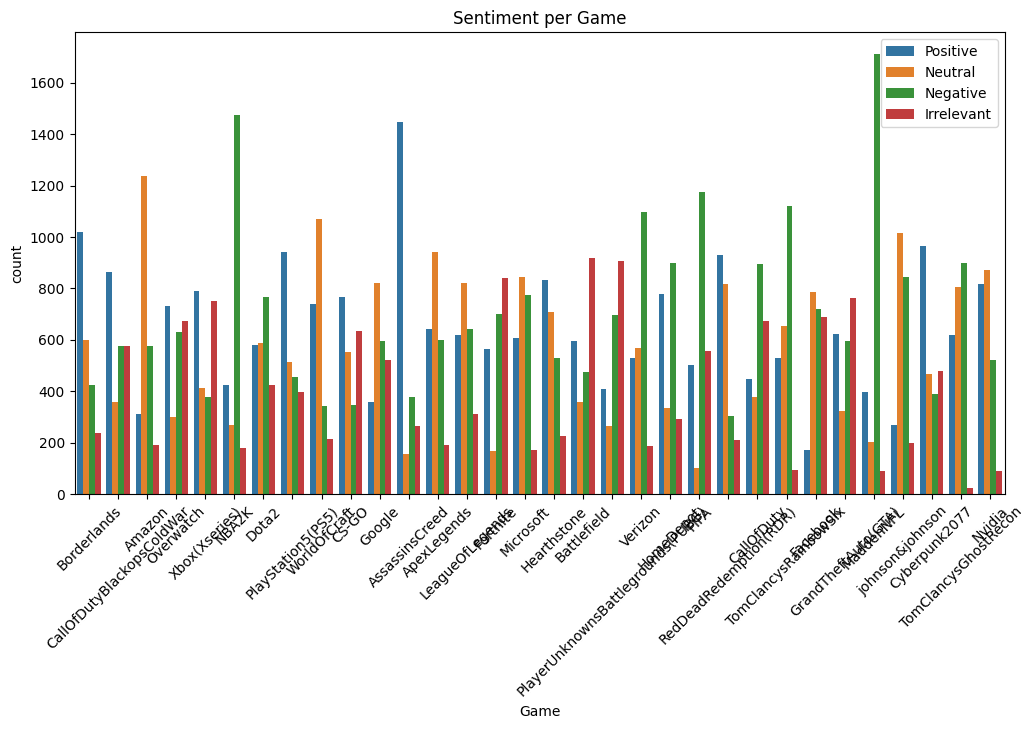

In [46]:
plt.figure(figsize=(12,6))
sns.countplot(data=data, x='Game', hue='Sentiment')
plt.title('Sentiment per Game')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.show()

In [47]:
data['Sentiment'].value_counts()

Sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [50]:
data['Game'].value_counts()

Game
TomClancysRainbowSix                 2400
MaddenNFL                            2400
Microsoft                            2400
LeagueOfLegends                      2394
CallOfDuty                           2394
Verizon                              2382
CallOfDutyBlackopsColdWar            2376
ApexLegends                          2376
Facebook                             2370
WorldOfCraft                         2364
Dota2                                2364
NBA2K                                2352
TomClancysGhostRecon                 2346
Battlefield                          2346
FIFA                                 2340
Xbox(Xseries)                        2334
Overwatch                            2334
johnson&johnson                      2328
Amazon                               2316
PlayStation5(PS5)                    2310
HomeDepot                            2310
Cyberpunk2077                        2304
CS-GO                                2304
GrandTheftAuto(GTA)          

In [52]:
from sklearn.utils import resample

In [59]:
df_pos = data[data['Sentiment']=='Positive']
df_neg = data[data['Sentiment']=='Negative']
df_neu = data[data['Sentiment']=='Neutral']
df_irr = data[data['Sentiment']=='Irrelevant']

In [60]:
min_size = min(len(df_pos), len(df_neg), len(df_neu), len(df_irr))

df_pos_down = resample(df_pos, replace=False, n_samples=min_size, random_state=42)
df_neg_down = resample(df_neg, replace=False, n_samples=min_size, random_state=42)
df_neu_down = resample(df_neu, replace=False, n_samples=min_size, random_state=42)
df_irr_down = resample(df_irr, replace=False, n_samples=min_size, random_state=42)

In [61]:
data_balanced = pd.concat([df_pos_down, df_neg_down, df_neu_down, df_irr_down])
print("Balanced dataset shape:", data_balanced.shape)

Balanced dataset shape: (51960, 4)


In [62]:
data=data_balanced

In [64]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   
    text = re.sub(r'@\w+', '', text)                     
    text = re.sub(r'#', '', text)                         
    text = re.sub(r'[^a-zA-Z\s]', '', text)               
    text = ' '.join(text.split())                          
    return text

data['clean_text'] = data['Text'].apply(clean_text)
data = data[data['clean_text'].str.len() > 0]

In [65]:
print(data[['Text', 'clean_text']].head())

                                                    Text  \
2505   Aye much I ’ ′ m gonna keep it a buck.... Cold...   
18758  Great summary of The Fourth War (The Blood War...   
65359             Derwin James is the best on this list.   
66793                         Loonngg due but good work!   
54463  i be so excited to get home and play call of d...   

                                              clean_text  
2505   aye much i m gonna keep it a buck cold war war...  
18758  great summary of the fourth war the blood war ...  
65359              derwin james is the best on this list  
66793                          loonngg due but good work  
54463  i be so excited to get home and play call of d...  


In [66]:
from sklearn.model_selection import train_test_split

X = data['clean_text']
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 41360, Test size: 10341


In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (41360, 5000)


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6514843825548786

Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.61      0.66      0.64      2585
    Negative       0.70      0.69      0.70      2586
     Neutral       0.64      0.60      0.62      2581
    Positive       0.65      0.65      0.65      2589

    accuracy                           0.65     10341
   macro avg       0.65      0.65      0.65     10341
weighted avg       0.65      0.65      0.65     10341



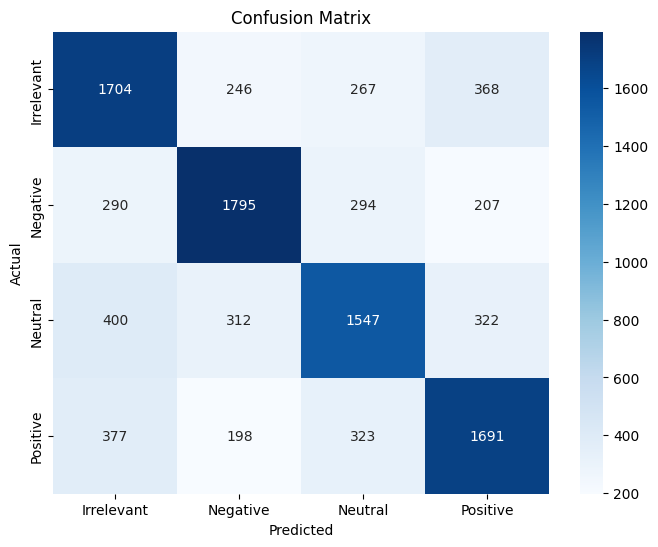

In [69]:
import numpy as np

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [70]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(tfidf, 'vectorizer.pkl')
print("Model and vectorizer saved!")

Model and vectorizer saved!


In [71]:
def predict_sentiment(text):
    import re
    # Clean the text (same as training)
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    
    # Vectorize
    vec = tfidf.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec).max()
    return pred, prob

# Example
sample = "I love this game! It's amazing."
sentiment, confidence = predict_sentiment(sample)
print(f"Text: {sample}")
print(f"Sentiment: {sentiment} (confidence: {confidence:.2f})")

Text: I love this game! It's amazing.
Sentiment: Positive (confidence: 0.94)
